In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import skew, kurtosis
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox
import ruptures as rpt
from statsmodels.stats.diagnostic import breaks_cusumolsresid
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM
import scipy.stats as st

In [26]:
df = pd.read_parquet('BTC_1h_logRV_dataset.parquet')
df.head()

,log_rv_lag1,rq_lag1,ret_lag1,abs_ret_lag1,hl_range_lag1,oc_range_lag1,log_volume_lag1,log_turnover_lag1,log_dollar_volume_lag1,log_rv_lag2,...,log_volume_mean_24h,log_rv_mean_72h,log_rv_std_72h,abs_ret_mean_72h,log_volume_mean_72h,log_rv_mean_168h,log_rv_std_168h,abs_ret_mean_168h,log_volume_mean_168h,target_log_rv
datetime,,,,,,,,,,,,,,,,,,,,,
2020-04-01 11:00:00+00:00,-11.263891,9.811790e-12,-0.000875,0.000875,0.004289,0.000875,6.021528,14.766553,14.765100,-10.329788,...,6.403800,-9.981787,0.785084,0.005595,6.222334,-9.911308,0.878312,0.005258,5.499272,-10.877429
2020-04-01 12:00:00+00:00,-10.877429,3.169461e-11,0.000080,0.000080,0.004777,0.000080,6.219327,14.962849,14.963415,-11.263891,...,6.391338,-9.990895,0.791682,0.005500,6.235605,-9.925606,0.874338,0.005186,5.500063,-8.289321
2020-04-01 13:00:00+00:00,-8.289321,2.262105e-08,-0.011440,0.011440,0.024213,0.011440,7.046194,15.783212,15.779963,-10.877429,...,6.409051,-9.977761,0.811983,0.005615,6.257070,-9.919777,0.881976,0.005188,5.504662,-9.743083
2020-04-01 14:00:00+00:00,-9.743083,9.248562e-10,-0.002820,0.002820,0.011788,0.002820,6.624831,15.356147,15.355324,-8.289321,...,6.404108,-9.964730,0.808052,0.005652,6.277851,-9.935079,0.855940,0.005204,5.507729,-10.303740
2020-04-01 15:00:00+00:00,-10.303740,8.555924e-11,0.006835,0.006835,0.009404,0.006835,6.778963,15.514746,15.516481,-9.743083,...,6.412864,-9.964258,0.807841,0.005704,6.298576,-9.945636,0.849421,0.005240,5.514985,-10.846316


In [27]:
target = df['target_log_rv']
dates = df.index

In [28]:
target.head()

datetime
2020-04-01 11:00:00+00:00   -10.877429
2020-04-01 12:00:00+00:00    -8.289321
2020-04-01 13:00:00+00:00    -9.743083
2020-04-01 14:00:00+00:00   -10.303740
2020-04-01 15:00:00+00:00   -10.846316
Name: target_log_rv, dtype: float64

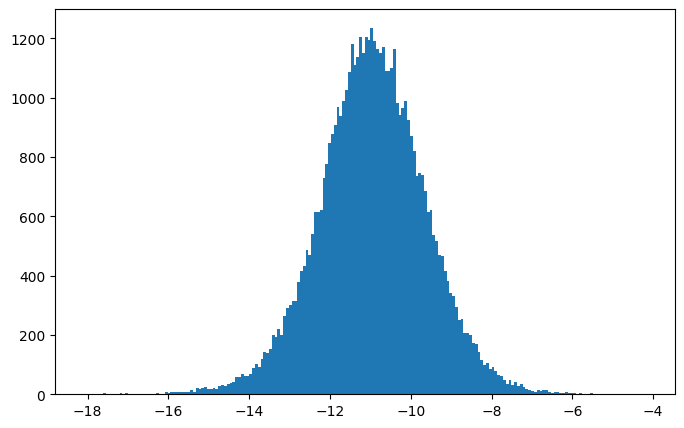

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(target, bins=200)
plt.show()

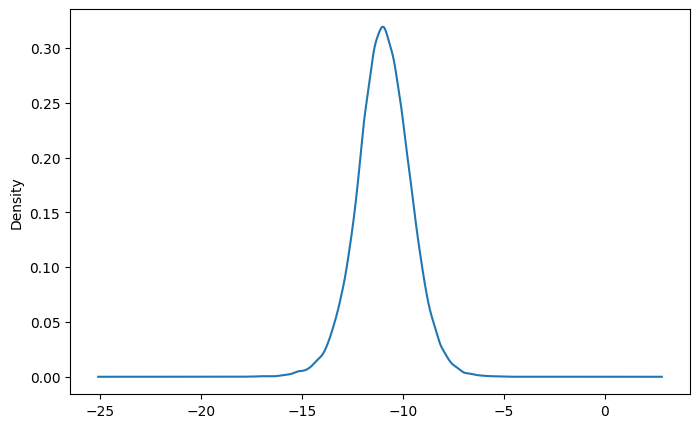

In [33]:
target.plot.kde(figsize=(8, 5))
plt.show()

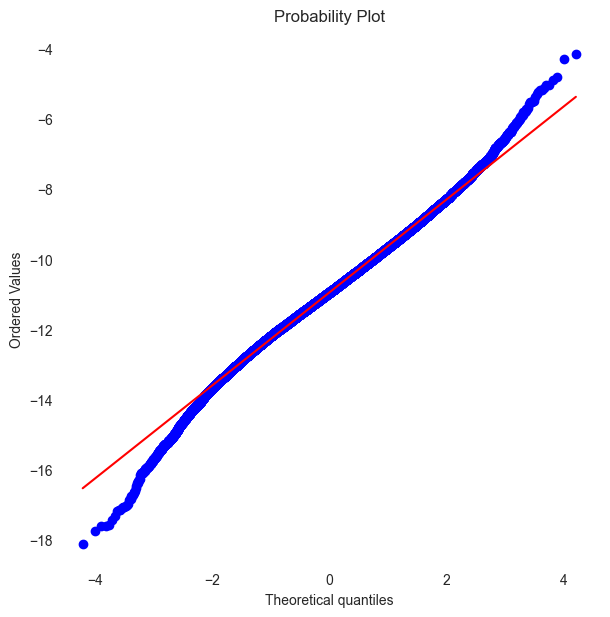

In [112]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor="white")
ax.set_facecolor("white")
stats.probplot(target, dist="norm", plot=ax)
plt.grid(alpha=0.15)
plt.savefig(
    "QQ_plot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white")
plt.show()

In [114]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

<Figure size 800x500 with 0 Axes>

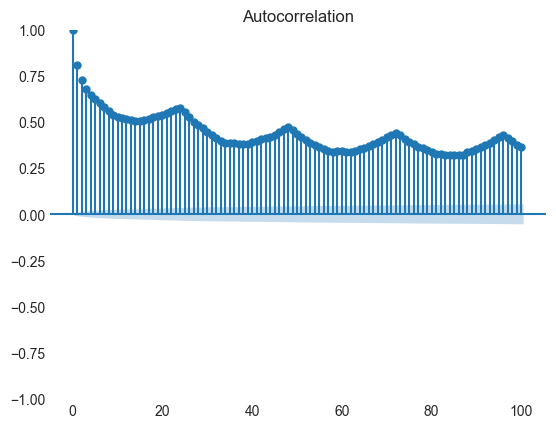

In [115]:
plt.figure(figsize=(8, 5))
plot_acf(target, lags=100)
plt.savefig('ACF.png')
plt.show()

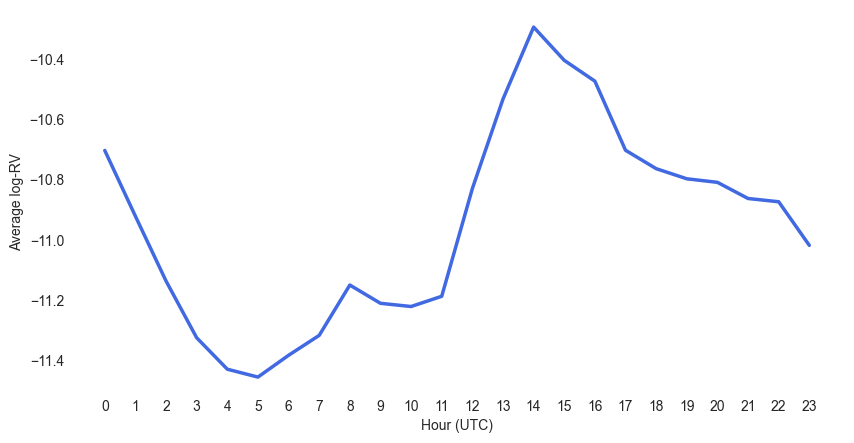

In [124]:
hourly_vol = target.groupby(target.index.hour).mean()
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_vol,
    color="royalblue",
    linewidth=2.5)
plt.xticks(range(24))
plt.xlabel("Hour (UTC)")
plt.ylabel("Average log-RV")
plt.grid(alpha=0.15)
plt.savefig("intraday_seasonality.png", dpi=300)
plt.show()

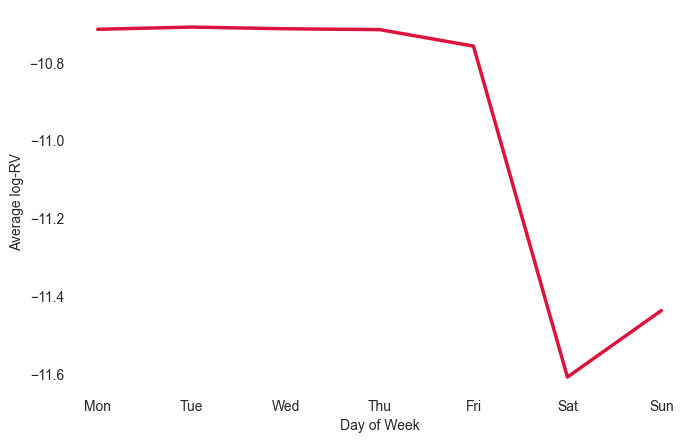

In [125]:
weekly_vol = target.groupby(target.index.dayofweek).mean()
plt.figure(figsize=(8, 5))
plt.plot(
    weekly_vol,
    color="crimson",
    linewidth=2.5)
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.xlabel("Day of Week")
plt.ylabel("Average log-RV")
plt.grid(alpha=0.15)
plt.savefig("weekly_seasonality.png", dpi=300)
plt.show()

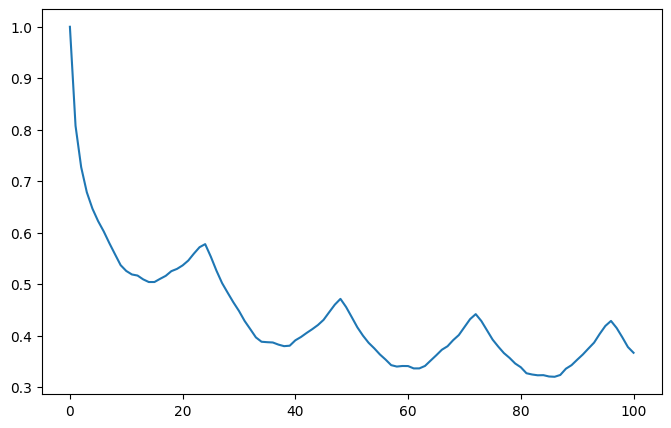

In [44]:
acf_values = acf(target, nlags=100)
plt.figure(figsize=(8, 5))
plt.plot(acf_values)
plt.show()

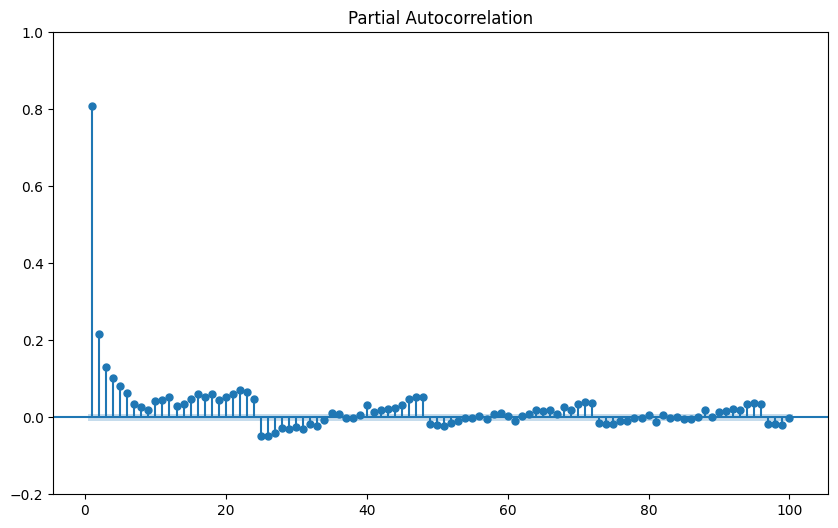

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(
    target,
    lags=100,
    method="ywm",
    alpha=0.05,
    zero=False,
    ax=ax
)
ax.set_ylim(-0.2, 1.0)
plt.show()

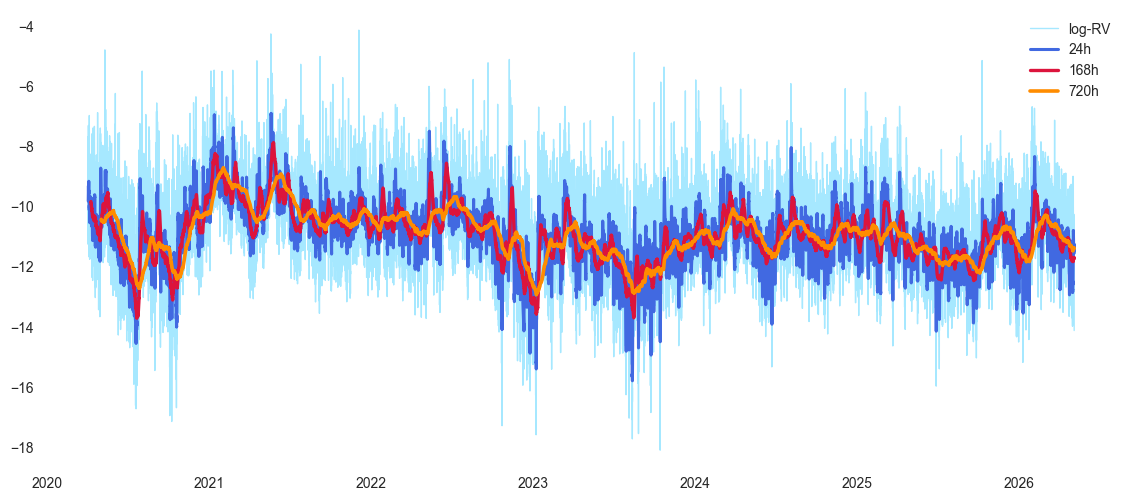

In [116]:
rolling_24h = target.rolling(24).mean()
rolling_168h = target.rolling(168).mean()
rolling_720h = target.rolling(720).mean()
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")
plt.plot(
    target,
    color="deepskyblue",
    alpha=0.35,
    linewidth=1,
    label="log-RV")
plt.plot(
    rolling_24h,
    color="royalblue",
    linewidth=2.2,
    label="24h")
plt.plot(
    rolling_168h,
    color="crimson",
    linewidth=2.4,
    label="168h")
plt.plot(
    rolling_720h,
    color="darkorange",
    linewidth=2.6,
    label="720h")
plt.legend(frameon=False)
plt.grid(alpha=0.15)
plt.savefig('rolmeanvol.png')
plt.show()

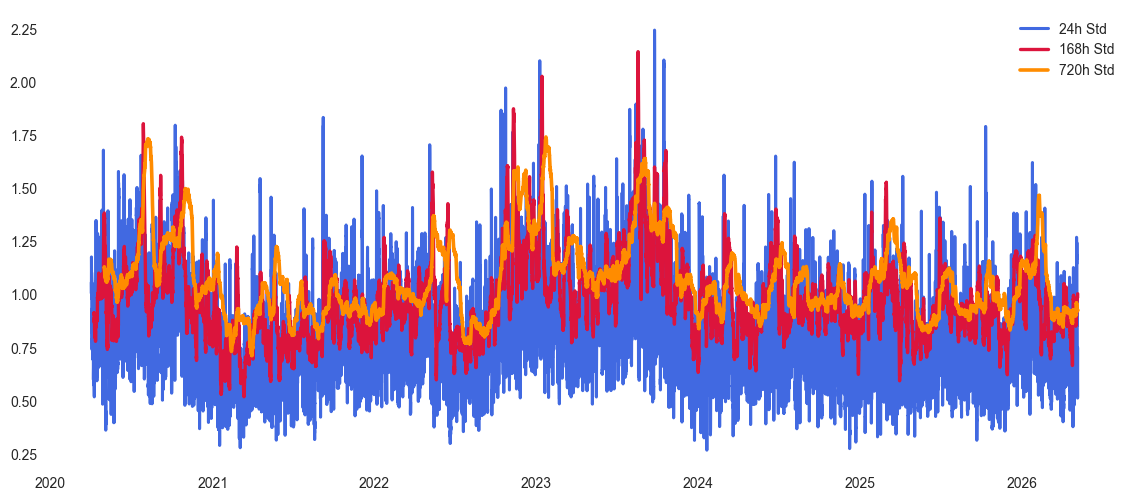

In [66]:
rolling_std_24h = target.rolling(24).std()
rolling_std_168h = target.rolling(168).std()
rolling_std_720h = target.rolling(720).std()
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")
plt.plot(
    rolling_std_24h,
    color="royalblue",
    linewidth=2.2,
    label="24h Std")
plt.plot(
    rolling_std_168h,
    color="crimson",
    linewidth=2.4,
    label="168h Std")
plt.plot(
    rolling_std_720h,
    color="darkorange",
    linewidth=2.6,
    label="720h Std")
plt.legend(frameon=False)
plt.grid(alpha=0.15)
plt.show()

In [70]:
adf_result = adfuller(target.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -13.53082792603356
p-value: 2.6237329338106164e-25
Critical Values:
1%: -3.4304725358270725
5%: -2.8615941583943583
10%: -2.5667988267090176


In [71]:
kpss_result = kpss(target.dropna(), regression="c")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")

for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 5.139538852106337
p-value: 0.01
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_51895/2631133704.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(target.dropna(), regression="c")


In [75]:
kpss_result = kpss(target.dropna(), regression="ct")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")
for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 0.9571329020501773
p-value: 0.01
Critical Values:
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


/var/folders/43/y646xgv56z72xq7sm281s4zr0000gn/T/ipykernel_51895/84599487.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(target.dropna(), regression="ct")


In [77]:
print("Skewness:", skew(target.dropna()))
print("Kurtosis:", kurtosis(target.dropna()))

Skewness: -0.08160042293380704
Kurtosis: 0.7249323199672033


In [119]:
lvl = pd.read_parquet('BTC_1h_RV_dataset.parquet')
targetlvl = lvl['target_rv']
dates = lvl.index

In [120]:
print("Skewness:", skew(targetlvl.dropna()))
print("Kurtosis:", kurtosis(targetlvl.dropna()))

Skewness: 39.597353449149864
Kurtosis: 2709.8112841139396


In [80]:
results = []
n = len(target.dropna())
for lag in range(1, 49):
    lm_stat, lm_pvalue, _, _ = het_arch(
        target.dropna(),
        nlags=lag
    )
    bic = np.log(n) * lag - 2 * np.log(lm_stat)
    results.append((lag, bic))
best_lag = min(results, key=lambda x: x[1])
print("Best lag:", best_lag[0])
print("Best BIC:", best_lag[1])

Best lag: 1
Best BIC: -10.059683560527374


In [81]:
arch_test = het_arch(target.dropna(), nlags=1)
print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F p-value:", arch_test[3])

LM Statistic: 35344.104994890346
LM p-value: 0.0
F Statistic: 104422.37312213864
F p-value: 0.0


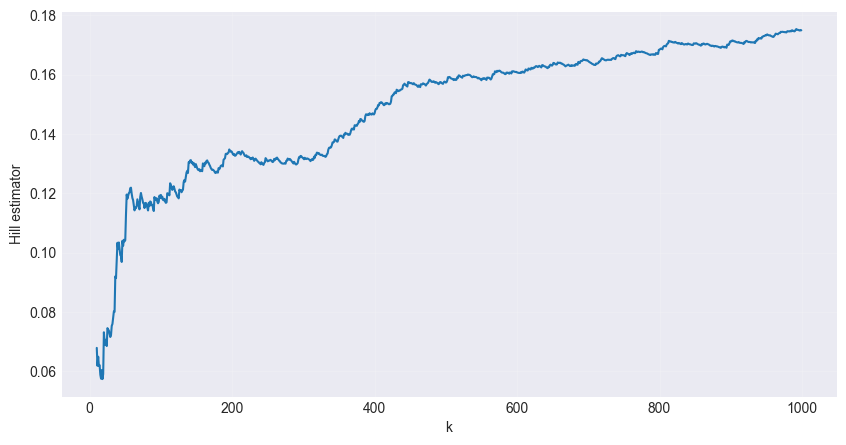

In [83]:
x = target.dropna().values
x = np.abs(x - np.mean(x))
x = np.sort(x)[::-1]
ks = np.arange(10, 1000)
hill = []
for k in ks:
    hill_k = np.mean(np.log(x[:k])) - np.log(x[k])
    hill.append(hill_k)
hill = np.array(hill)
plt.figure(figsize=(10, 5))
plt.plot(ks, hill)
plt.xlabel("k")
plt.ylabel("Hill estimator")
plt.grid(alpha=0.15)
plt.show()

In [85]:
k = 1000
hill_alpha = 1 / (np.mean(np.log(x[:k])) - np.log(x[k]))
print("Tail index alpha:", hill_alpha)

Tail index alpha: 5.717431095388156


In [86]:
k = 100
hill_alpha = 1 / (np.mean(np.log(x[:k])) - np.log(x[k]))
print("Tail index alpha:", hill_alpha)

Tail index alpha: 8.370349447067692


In [87]:
k = 300
hill_alpha = 1 / (np.mean(np.log(x[:k])) - np.log(x[k]))
print("Tail index alpha:", hill_alpha)

Tail index alpha: 7.5900676905031395


In [90]:
u = np.quantile(x, 0.95)
exceedances = x[x > u] - u
shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
print("Threshold:", u)
print("Number of exceedances:", len(exceedances))
print("Shape xi:", shape)
print("Scale beta:", scale)

Threshold: 2.628943018923942
Number of exceedances: 2672
Shape xi: -0.01940754475130404
Scale beta: 0.6922613767632764


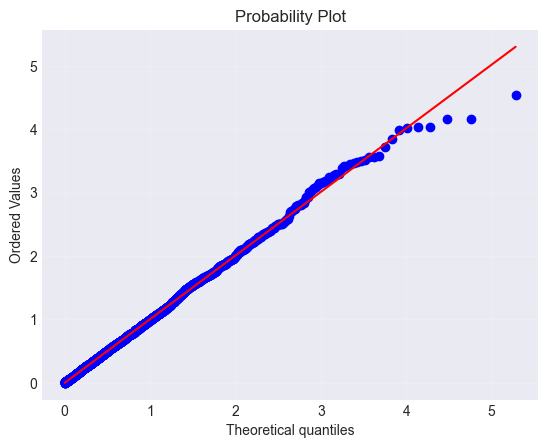

In [92]:
stats.probplot(exceedances, dist=stats.genpareto, sparams=(shape, loc, scale), plot=plt)
plt.grid(alpha=0.15)
plt.show()

In [94]:
def hurst_exponent(x, min_lag=2, max_lag=100):
    x = np.asarray(x.dropna())
    lags = np.arange(min_lag, max_lag)
    tau = [
        np.std(x[lag:] - x[:-lag])
        for lag in lags]
    slope = np.polyfit(np.log(lags), np.log(tau), 1)[0]
    return slope
H = hurst_exponent(target, min_lag=2, max_lag=200)
print("Hurst exponent:", H)

Hurst exponent: 0.059587735549580745


In [137]:
y = target.dropna()
X = sm.add_constant(np.arange(len(y)))
model = sm.OLS(y.values, X).fit()
cusum_stat, p_value, crit = breaks_cusumolsresid(model.resid)
print("CUSUM statistic:", cusum_stat)
print("p-value:", p_value)
print("critical values:", crit)

CUSUM statistic: 16.085974839740768
p-value: 3.5170410126172835e-225
critical values: [(1, 1.63), (5, 1.36), (10, 1.22)]


In [95]:
x = target.dropna().values
x = x - x.mean()
n = len(x)
m = int(n ** 0.5)
freq = 2 * np.pi * np.arange(1, m + 1) / n
periodogram = np.abs(np.fft.fft(x)) ** 2 / (2 * np.pi * n)
I = periodogram[1:m + 1]
z = np.log(4 * np.sin(freq / 2) ** 2)
y_gph = np.log(I)
d_hat = -0.5 * np.polyfit(z, y_gph, 1)[0]
print("GPH d estimate:", d_hat)

GPH d estimate: 0.3087928243184088


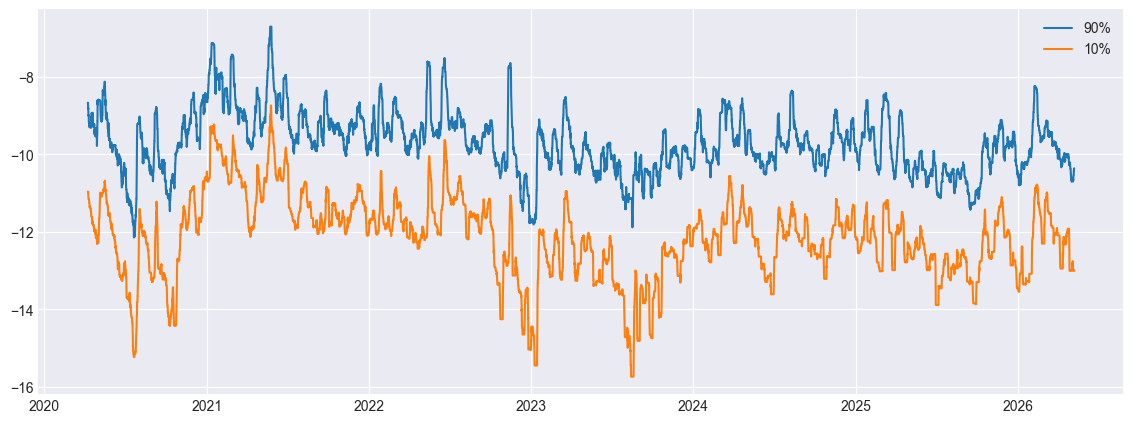

In [107]:
q90 = target.rolling(168).quantile(0.9)
q10 = target.rolling(168).quantile(0.1)
plt.figure(figsize=(14, 5))
plt.plot(q90, label="90%")
plt.plot(q10, label="10%")
plt.legend()
plt.show()

In [109]:
lb = acorr_ljungbox(target, lags=[24], return_df=True)
print(lb)

          lb_stat  lb_pvalue
24  425680.544901        0.0
